# Dataset Iris

Referência
- [The Iris Dataset](https://scikit-learn.org/1.4/auto_examples/datasets/plot_iris_dataset.html)

## Imports

In [ ]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import keras
import torch

from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Carregar Dataset

In [2]:
iris = datasets.load_iris()

features = iris.data
labels = iris.target
classes = iris.target_names

## Sobre os Dados

### Visualizar

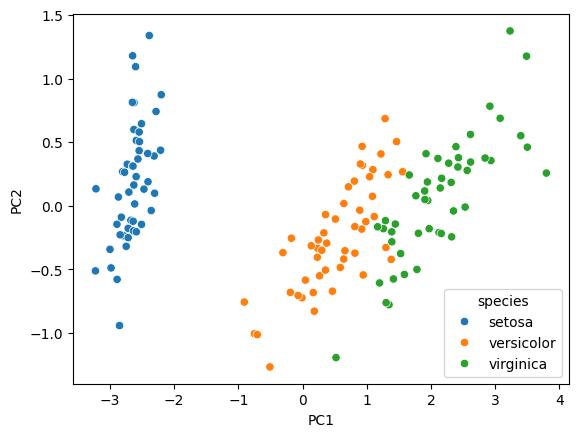

In [3]:
pca = PCA(n_components=2)
components = pca.fit_transform(features)

df_pca = pd.DataFrame(components, columns=["PC1", "PC2"])
aux_df = pd.DataFrame(labels, columns=["species"])

df_pca["species"] = aux_df["species"].map(lambda i: classes[i])

sns.scatterplot(df_pca, x="PC1", y="PC2", hue="species")
plt.show()

### Preparar

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

### Normalizar

In [5]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## Sobre o Modelo

### Montar

In [6]:
model = keras.Sequential([
    keras.Input(shape=(4,), name='input_layer'),
    keras.layers.Dense(16, activation="relu", name='dense_input_layer'),
    keras.layers.Dense(8, activation="relu", name='dense_hidden_layer'),
    keras.layers.Dense(3, activation="softmax", name='dense_output_layer')
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_input_layer (Dense)       │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden_layer (Dense)      │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_output_layer (Dense)      │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

### Treinamento

#### Alocar GPU

O treinamento roda na GPU do Apple Silicon (Mac mini M4) por meio do
backend **PyTorch** do Keras 3, que utiliza o dispositivo **MPS**
(Metal Performance Shaders).

A alocação do dispositivo é automática — o backend PyTorch seleciona o
MPS quando disponível — e a célula seguinte apenas confirma qual
dispositivo está em uso.

In [11]:
os.environ["KERAS_BACKEND"] = "torch"
device = "mps" if torch.backends.mps.is_available() else "cpu"

print(f"Keras backend: {keras.backend.backend()}")
print(f"Training device: {device}")

Keras backend: torch
Training device: mps


#### Treinar

In [8]:
logs = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2812 - loss: 1.0989 - val_accuracy: 0.3750 - val_loss: 1.0428
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4479 - loss: 1.0276 - val_accuracy: 0.4583 - val_loss: 0.9895
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5833 - loss: 0.9640 - val_accuracy: 0.5417 - val_loss: 0.9393
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6667 - loss: 0.9070 - val_accuracy: 0.6667 - val_loss: 0.8911
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7917 - loss: 0.8511 - val_accuracy: 0.6667 - val_loss: 0.8449
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8125 - loss: 0.8004 - val_accuracy: 0.6667 - val_loss: 0.8020
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8021 - loss: 0.7536 - val_accuracy: 0.6667 - val_loss: 0.7626
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8125 - loss: 0.7117 - val_accuracy: 0.6667 - val_loss:

### Avaliar

In [9]:
lss, acc = model.evaluate(x_test, y_test, verbose=1)

print("lss:", lss)
print("acc:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9000 - loss: 0.2557
lss: 0.2557116746902466
acc: 0.8999999761581421


### Fazer Predição

In [10]:
preds = model.predict(x_test)

pred_class = np.argmax(preds, axis=1)
pred_class

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


array([0, 2, 1, 1, 0, 2, 0, 0, 2, 1, 2, 2, 2, 2, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 2, 2, 2, 1, 0, 2, 0])